# Mock Member Health Analysis - Model_interpretation

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

## 2. Load Processed Dataset

In [2]:
df = pd.read_csv("../data/processed/member_analysis_ready.csv")
df.head()

,member_id,age,gender,region,plan_type,chronic_condition_count,engagement_score,ed_visits,ip_admits,monthly_cost,awv_completed,engagement_group,age_group,high_cost_member,has_acute_utilization,chronic_burden_group
0,M00001,69,Female,Rural,DSNP,3,72.6,1,1,2634.13,0,Q4,65-79,True,1,Moderate
1,M00002,32,Female,Suburban,Medicare Advantage,0,71.5,0,1,1632.38,1,Q4,18-34,False,1,Low
2,M00003,89,Male,Suburban,Medicaid,2,32.6,0,0,978.36,1,Q1,80+,False,0,Moderate
3,M00004,78,Male,Suburban,Medicare Advantage,7,56.0,3,0,2761.83,1,Q3,65-79,True,1,High
4,M00005,38,Female,Urban,DSNP,2,42.2,0,1,2001.45,1,Q1,35-49,True,1,Moderate


In [3]:
target = "awv_completed"

X = df.drop(columns = ["member_id", target]) # Drop member_id because it is an identifier and has no predictive meaning. Drop target to separate features from the target variable.
y = df[target] # Define the target variable

## 3. Rebuild Baseline Logistic Regression

In [4]:
X_train, X_test, y_train, y_test = train_test_split( 
    X,y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
) # Stratify by y to maintain the same proportion of classes in both training and testing sets, which is important for classification problems.


In [5]:
categorical_cols = X.select_dtypes(include = ["object", "category"]).columns.tolist() # Identify categorical columns by selecting columns with data types "object" or "category". This will be used for one-hot encoding in the preprocessing pipeline.
numeric_cols = X.select_dtypes(include = ["int64", "float64", "int32", "float32"]).columns.tolist() # Identify numeric columns by selecting columns with data types "int64", "float64", "int32", or "float32". This will be used for scaling in the preprocessing pipeline.

C:\Users\kdy10\AppData\Local\Temp\ipykernel_13028\1452006186.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include = ["object", "category"]).columns.tolist() # Identify categorical columns by selecting columns with data types "object" or "category". This will be used for one-hot encoding in the preprocessing pipeline.


In [6]:
#Preprocessor

preprocessor = ColumnTransformer(
    transformers = [
        ("cat", OneHotEncoder(drop="first", handle_unknown = "ignore"), categorical_cols),
         ("num", "passthrough", numeric_cols)
    ]
) # Create a ColumnTransformer that applies OneHotEncoder to categorical columns (dropping the first category to avoid multicollinearity) and passes through numeric columns without transformation. The handle_unknown = "ignore" parameter ensures that any unseen categories in the test set will be ignored rather than causing an error during transformation.
 

In [7]:
log_model = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=3000)) 
])
log_model.fit(X_train, y_train) # Fit the logistic regression model to the training data using the defined pipeline, which includes preprocessing steps for both categorical and numeric features. The max_iter=3000 parameter is set to ensure convergence of the logistic regression algorithm, especially if the dataset is large or has many features.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 4.Review Class Balance

In [8]:
df["awv_completed"].value_counts(normalize = True) # Check the distribution of the target variable to understand class imbalance, which can impact model performance and may require techniques such as resampling or class weighting if the classes are highly imbalanced.


awv_completed
1    0.696
0    0.304
Name: proportion, dtype: float64

## 5. Evaluate Predictions More Deeply

In [9]:
y_pred = log_model.predict(X_test) # Generate predicted class labels for the test set using the fitted logistic regression model. This will be used to evaluate the model's performance in terms of classification metrics such as accuracy, precision, recall, and F1-score.
y_prob = log_model.predict_proba(X_test)[:,1] # Generate predicted probabilities for the positive class (class 1) for the test set using the fitted logistic regression model. This will be used for evaluating the model's performance in terms of probabilistic metrics such as AUC-ROC.

In [10]:
print("Accuracy", accuracy_score(y_test, y_pred))  # Print the accuracy of the model, which is the proportion of correct predictions (both true positives and true negatives) out of the total number of predictions made. This metric gives an overall sense of how well the model is performing, but it can be misleading in cases of class imbalance, which is why it's important to also consider precision, recall, and F1-score.
print("Precision", precision_score(y_test, y_pred))  # Print the precision of the model, which is the proportion of true positive predictions out of the total number of positive predictions made. This metric is useful when the cost of false positives is high.
print("Recall", recall_score(y_test, y_pred))  # Print the recall of the model, which is the proportion of true positive predictions out of the total number of actual positive instances. This metric is useful when the cost of false negatives is high.
print("F1 Score", f1_score(y_test, y_pred))  # Print the F1-score of the model, which is the harmonic mean of precision and recall. This metric provides a balance between precision and recall and is useful when you want to consider both types of errors.
print("ROC AUC:", roc_auc_score(y_test, y_prob))  # Print the ROC AUC score of the model, which measures the ability of the model to distinguish between classes. A higher AUC indicates better performance.
print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred))
print("\nClassification Report:")
print(classification_report(y_test,y_pred))

Accuracy 0.71
Precision 0.735632183908046
Recall 0.9142857142857143
F1 Score 0.8152866242038217
ROC AUC: 0.6533333333333333

Confusion Matrix:
[[ 7 23]
 [ 6 64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.23      0.33        30
           1       0.74      0.91      0.82        70

    accuracy                           0.71       100
   macro avg       0.64      0.57      0.57       100
weighted avg       0.68      0.71      0.67       100



## 6.Interpret Logistic Regression Coefficients

### Step A: get transformed feature names

In [11]:
ohe = log_model.named_steps["preprocessor"].named_transformers_["cat"] # Access the OneHotEncoder from the preprocessing step of the pipeline to retrieve the feature names for the encoded categorical variables. This will allow us to understand which features correspond to which original categorical variables after encoding.
encoded_cat_features = ohe.get_feature_names_out(categorical_cols) # Get the feature names for the encoded categorical variables using the get_feature_names_out method of the OneHotEncoder, which will return the new feature names after encoding based on the original categorical column names.
all_feature_names = list(encoded_cat_features) + numeric_cols # Combine the encoded categorical feature names with the original numeric column names to create a complete list of feature names that correspond to the features used in the logistic regression model after preprocessing.

### Step B: get coefficients

In [12]:
coefficients = log_model.named_steps["model"].coef_[0] # Extract the coefficients from the logistic regression model. The coef_ attribute contains the coefficients for each feature in the order they were processed by the pipeline. Since this is a binary classification problem, we take the first element of the array to get the coefficients for the positive class.
coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending = False)

coef_df.head(15)


,feature,coefficient,abs_coefficient
10,age_group_65-79,-0.649732,0.649732
5,engagement_group_Q2,0.405322,0.405322
11,age_group_80+,0.373398,0.373398
0,gender_Male,0.271510,0.271510
12,chronic_burden_group_Low,0.265277,0.265277
2,region_Urban,0.217658,0.217658
17,ed_visits,-0.207230,0.207230
8,age_group_35-49,0.117395,0.117395
1,region_Suburban,-0.100555,0.100555
15,chronic_condition_count,0.077665,0.077665


## 7. Test Different Classification Threshold

In [13]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7] # Define a range of thresholds to evaluate how the model's performance metrics change when we classify instances as positive based on different probability cutoffs. This is important because the default threshold of 0.5 may not always be optimal, especially in cases of class imbalance or when the costs of false positives and false negatives are different.

threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_thresh),
        "precision": precision_score(y_test, y_pred_thresh, zero_division = 0),
        "recall": recall_score(y_test, y_pred_thresh, zero_division = 0 ),
        "f1_score": f1_score(y_test, y_pred_thresh, zero_division = 0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df


,threshold,accuracy,precision,recall,f1_score
0,0.3,0.69,0.696970,0.985714,0.816568
1,0.4,0.74,0.734043,0.985714,0.841463
2,0.5,0.71,0.735632,0.914286,0.815287
3,0.6,0.69,0.753247,0.828571,0.789116
4,0.7,0.62,0.775862,0.642857,0.703125


## 8. Compare Threshold Tradeoffs

In [14]:
best_f1_row = threshold_df.sort_values("f1_score", ascending = False).iloc[0] # Sort the threshold results by F1-score in descending order and select the row with the highest F1-score to identify the optimal threshold for classification based on the balance of precision and recall.
best_f1_row


threshold    0.400000
accuracy     0.740000
precision    0.734043
recall       0.985714
f1_score     0.841463
Name: 1, dtype: float64

## Findings 

1. The Target Variable is imbalanced toward AWV-completed members, so accuracy alone overstates model quality.
2. Logistic regression shows which features are postiviely or negatively associated with predicted AWV completion
3. If engagement-related features have positive coefficients, the model estimates that higher engagement is associated with higher log-odds, and    therefore higher predicted odds, of AWV completion, holding other included variables constant
4. Model performance changes meaningfully across classification thresholds, showing that the default 0.50 cutoff is only one operating choice.
5. These relationships reflect learned patterns in synthetic data and should not be interpreted as causal effects. 

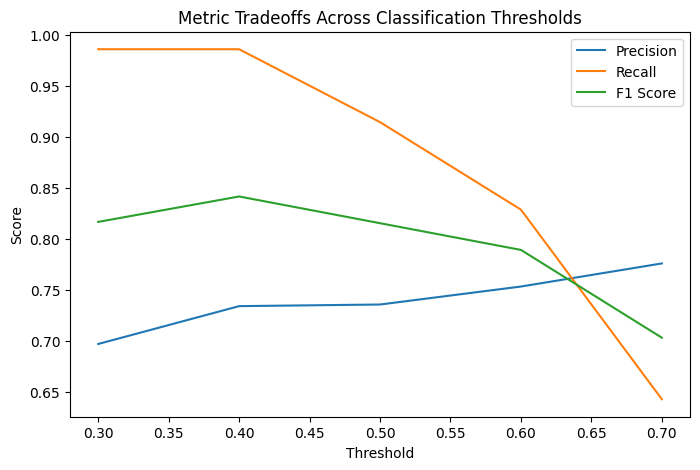

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1_score"], label="F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Metric Tradeoffs Across Classification Thresholds")
plt.legend()
plt.show()